In [1]:
import sys
import importlib
import os
sys.path.append(os.path.abspath(".."))

import pipeline.io as io
import pipeline.data_handler as dh
import matplotlib.pyplot as plt



In [2]:
"""Plotting code to visual the dataframes as they go through the pipeline"""
def plot_lightcurve(df):
    plt.figure(figsize=(8, 5))

    plt.plot(df[0], df[1], '.', markersize=4)

    plt.xlabel("Time")
    plt.ylabel("Magnitude")
    plt.title("Lightcurve")
    plt.axhline(0)

    plt.gca().invert_yaxis()  # important for astronomy magnitudes

    plt.tight_layout()
    plt.show()

In [3]:
print(dir(io))

['Path', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'create_file_list', 'csv_handler', 'json_handler', 'lightcurve_reader', 'multi_lightcurve_reader', 'pd', 'tab_handler', 'txt_handler', 'xml_handler']


In [4]:
valid_tab_path = '/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970305.tab'
valid_xml_path = '/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970203.xml'

In [5]:
data_valid_tab, metadata, code_valid_tab = io.lightcurve_reader(valid_tab_path)
print(data_valid_tab, code_valid_tab)

[             0       1
0  50512.79195  19.015
1  50512.86314  19.057
2  50512.91949  19.031] 0


In [6]:
data_valid_xml, metadata,code_valid_xml = io.lightcurve_reader(valid_xml_path)
print(data_valid_xml, code_valid_xml)

Reading of file: /Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970203.xml failed.
None -1


In [7]:
print(io.create_file_list('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999', 'tab', id_string='13651'))



files = io.create_file_list('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999', 'tab', id_string='35107')
print(files[0])
files_0 = [files[2]]
print(files)

data, metadata, exit_status = io.multi_lightcurve_reader(files)
print(data)
print(len(files))
print(len(data))
print(metadata)

[PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970209.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970224.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970226.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970131.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970301.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970303.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970302.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970307.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970305.tab'), 

In [8]:
importlib.reload(dh)


<module 'pipeline.data_handler' from '/Users/smores/Desktop/school/S26/computationalastro/Asteroid-Period-Finder/pipeline/data_handler.py'>

In [9]:
data, metadata, exit_status = io.lightcurve_reader('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/35107_19970310.tab')

In [10]:
data, metadata, exit_status = io.lightcurve_reader('/Users/smores/Desktop/school/S26/computationalastro/Asteroid-Period-Finder/data/ALCDEF/ALCDEF_40_Harmonia_20260506_002252.txt')

In [11]:
print(metadata)

[{'REVISEDDATA': 'FALSE', 'ALLOWSHARING': 'TRUE', 'SUBMITPDS': 'TRUE', 'LASTUPDATE': '2018-12-07 00:00:00', 'LCBLOCKID': '473', 'OBJECTNUMBER': '40', 'OBJECTNAME': 'Harmonia', 'MPCDESIG': '', 'SESSIONDATE': '2008-12-19', 'SESSIONTIME': '11:24:26', 'CONTACTNAME': 'F. Pilcher', 'CONTACTINFO': '[pilcher@ic.edu]', 'OBSERVERS': 'F. Pilcher', 'FACILITY': 'Organ Mesa Observatory', 'MPCCODE': 'G50', 'TELESCOPE': '0.35-m SCT', 'DETECTOR': 'SBIG STL-1001E', 'OBSLONGITUDE': '-106.670000', 'OBSLATITUDE': '+32.296111', 'EXPOSURE': '-99', 'EXPJD': 'MID', 'OBJECTRA': '08:00.3', 'OBJECTDEC': '+21 57', 'EQUINOX': 'J2000.0', 'PHASE': '+12.41', 'PABL': '+111.5', 'PABB': '+1.1', 'FILTER': 'R', 'MAGBAND': 'R', 'CICORRECTION': 'FALSE', 'CIBAND': 'NONE', 'CITARGET': '-99.9', 'DIFFERMAGS': 'TRUE', 'DIFFZEROMAG': '-99.9', 'STANDARD': 'NONE', 'LTCAPP': 'NONE', 'REDUCEDMAGS': 'NONE', 'PUBLICATION': 'BIBCODE=COMMENT=The original SessionDate/Time were adjusted to match the average JD of the lightcurve data', 'DELI

In [12]:
processed = dh.process_lightcurve(data, metadata)

Pass 1: mean subtraction normalization...
Pass 1: running Lomb-Scargle...
Pass 1 LS peak: 5.3884 c/d → frot = 2.6942 c/d (P = 8.908 hr)
Pass 1 global coeffs: C=0.0004 A1=-0.0119 B1=-0.0087 A2=0.0432 B2=-0.0773

Pass 2: global coefficient normalization...


In [13]:
import pipeline.fourier_engine as fe
import numpy as np

importlib.reload(fe)

frequencies, powers, fpeak = fe.lomb_scargle(processed['jd_corrected'], processed[1])

print(fpeak)

5.388383561643854


In [14]:
print(processed)
print((processed['jd_corrected'] - processed[0]).describe())

                 0         1  uncertainty  jd_corrected
0     2.454820e+06 -0.114634        0.006  2.454820e+06
1     2.454820e+06 -0.135592        0.006  2.454820e+06
2     2.454820e+06 -0.139574        0.006  2.454820e+06
3     2.454820e+06 -0.120553        0.005  2.454820e+06
4     2.454820e+06 -0.120533        0.005  2.454820e+06
...            ...       ...          ...           ...
1952  2.455362e+06  0.019202        0.006  2.455362e+06
1953  2.455362e+06  0.004182        0.006  2.455362e+06
1954  2.455362e+06  0.020161        0.006  2.455362e+06
1955  2.455362e+06  0.013120        0.006  2.455362e+06
1956  2.455362e+06  0.015104        0.006  2.455362e+06

[1957 rows x 4 columns]
count    1957.000000
mean       -0.007723
std         0.000151
min        -0.007957
25%        -0.007868
50%        -0.007647
75%        -0.007585
max        -0.007575
dtype: float64


                0      1  uncertainty
0    2.454820e+06 -1.544        0.006
1    2.454820e+06 -1.565        0.006
2    2.454820e+06 -1.569        0.006
3    2.454820e+06 -1.550        0.005
4    2.454820e+06 -1.550        0.005
..            ...    ...          ...
135  2.454820e+06 -1.440        0.004
136  2.454820e+06 -1.453        0.003
137  2.454820e+06 -1.454        0.004
138  2.454820e+06 -1.452        0.004
139  2.454820e+06 -1.450        0.004

[140 rows x 3 columns]
{'REVISEDDATA': 'FALSE', 'ALLOWSHARING': 'TRUE', 'SUBMITPDS': 'TRUE', 'LASTUPDATE': '2018-12-07 00:00:00', 'LCBLOCKID': '473', 'OBJECTNUMBER': '40', 'OBJECTNAME': 'Harmonia', 'MPCDESIG': '', 'SESSIONDATE': '2008-12-19', 'SESSIONTIME': '11:24:26', 'CONTACTNAME': 'F. Pilcher', 'CONTACTINFO': '[pilcher@ic.edu]', 'OBSERVERS': 'F. Pilcher', 'FACILITY': 'Organ Mesa Observatory', 'MPCCODE': 'G50', 'TELESCOPE': '0.35-m SCT', 'DETECTOR': 'SBIG STL-1001E', 'OBSLONGITUDE': '-106.670000', 'OBSLATITUDE': '+32.296111', 'EXPOSURE

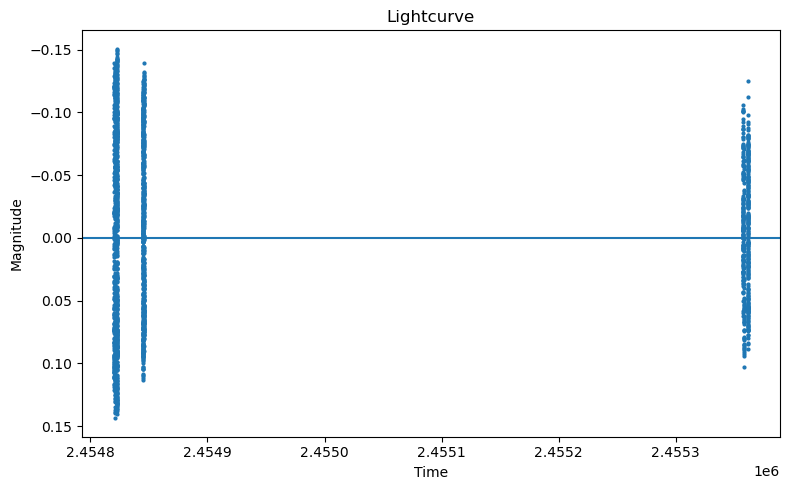

In [15]:
print(data[0])
print(metadata[0])

print(metadata[0]['LTCAPP'])


plot_lightcurve(processed)

Top 10 peaks:
Rank   Frequency (c/d)      Period (hr)     Power     
-------------------------------------------------------
1      5.3884               4.454           790.6162  
2      5.3865               4.456           781.4205  
3      5.3903               4.452           773.7499  
4      5.3845               4.457           747.2685  
5      5.3867               4.455           731.6886  
6      5.3922               4.451           731.3669  
7      5.3887               4.454           721.1259  
8      5.3456               4.490           719.7547  
9      5.3848               4.457           718.1253  
10     5.4311               4.419           714.8277  

Known double frequency: 1.4502 c/d (P = 16.55 hr)


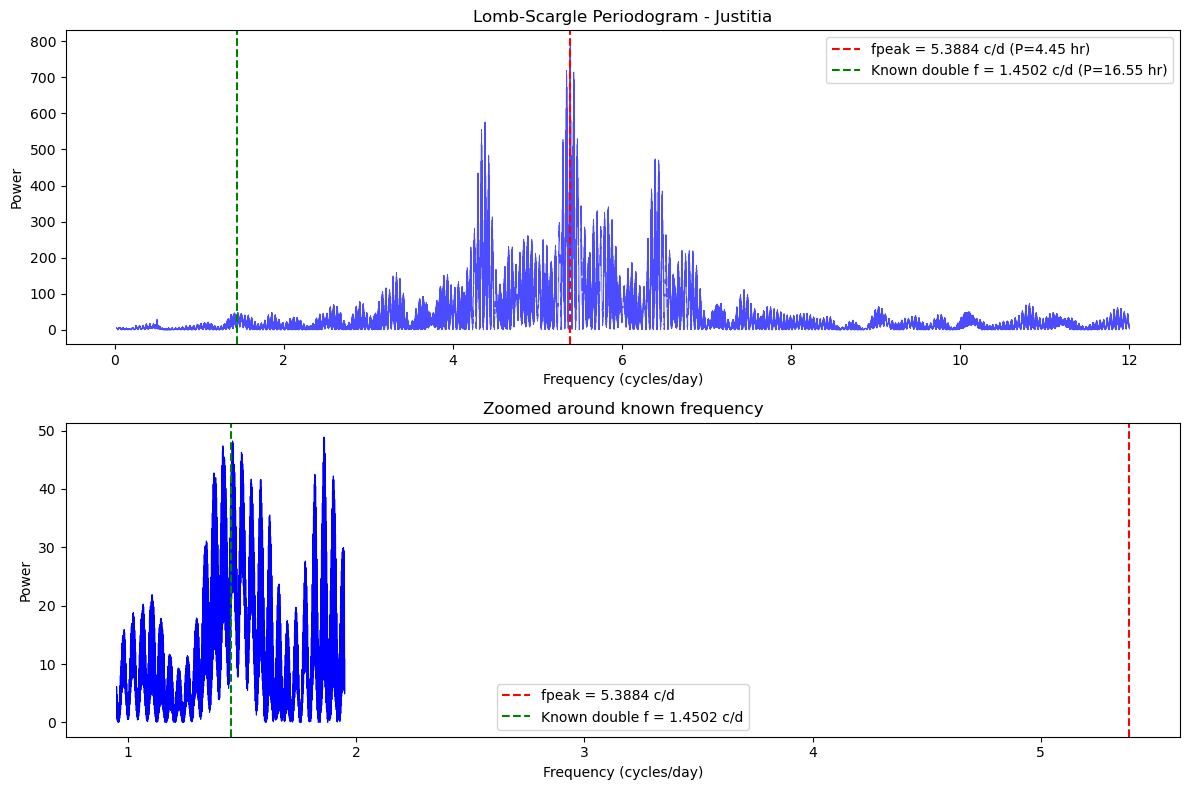

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 peaks
top10_idx = np.argsort(powers)[-10:][::-1]
print("Top 10 peaks:")
print(f"{'Rank':<6} {'Frequency (c/d)':<20} {'Period (hr)':<15} {'Power':<10}")
print("-" * 55)
for rank, idx in enumerate(top10_idx):
    f = frequencies[idx]
    p = 24 / f
    print(f"{rank+1:<6} {f:<20.4f} {p:<15.3f} {powers[idx]:<10.4f}")

# mark known frequency
f_known_double = 2 * (24/33.1)
print(f"\nKnown double frequency: {f_known_double:.4f} c/d (P = {24/f_known_double:.2f} hr)")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Full periodogram
ax1.plot(frequencies, powers, 'b-', linewidth=0.5, alpha=0.7)
ax1.axvline(fpeak, color='red', linestyle='--', label=f'fpeak = {fpeak:.4f} c/d (P={24/fpeak:.2f} hr)')
ax1.axvline(f_known_double, color='green', linestyle='--', label=f'Known double f = {f_known_double:.4f} c/d (P={24/f_known_double:.2f} hr)')
ax1.set_xlabel('Frequency (cycles/day)')
ax1.set_ylabel('Power')
ax1.set_title('Lomb-Scargle Periodogram - Justitia')
ax1.legend()

# Zoomed in around the true frequency
f_center = f_known_double
f_window = 0.5
mask = (frequencies >= f_center - f_window) & (frequencies <= f_center + f_window)
ax2.plot(frequencies[mask], powers[mask], 'b-', linewidth=0.8)
ax2.axvline(fpeak, color='red', linestyle='--', label=f'fpeak = {fpeak:.4f} c/d')
ax2.axvline(f_known_double, color='green', linestyle='--', label=f'Known double f = {f_known_double:.4f} c/d')
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_ylabel('Power')
ax2.set_title('Zoomed around known frequency')
ax2.legend()

plt.tight_layout()
plt.show()

In [17]:
import pipeline.harmonic_logic as hl
importlib.reload(hl)


best_frot, period_hours, best_coeffs, is_double_peaked = hl.harmonic_logic(
    processed['jd_corrected'].values, 
    processed[1].values, 
    frequencies, 
    powers
)


Found 1 clusters, refining each...
  f_ls=5.3884 c/d | single: frot=5.3884 (P=4.454 hr) chi2=0.000703 | double: frot=2.6932 (P=8.911 hr) chi2=0.000887

Best rotation frequency: 5.388437 c/d
Best period: 4.4540 hours
Chi2 single: 0.000965
Chi2 double: 0.000703
Harmonic amplitude ratio: 0.2601
Double peaked: True


Figure saved to ../outputs/269 Justitia_results.png


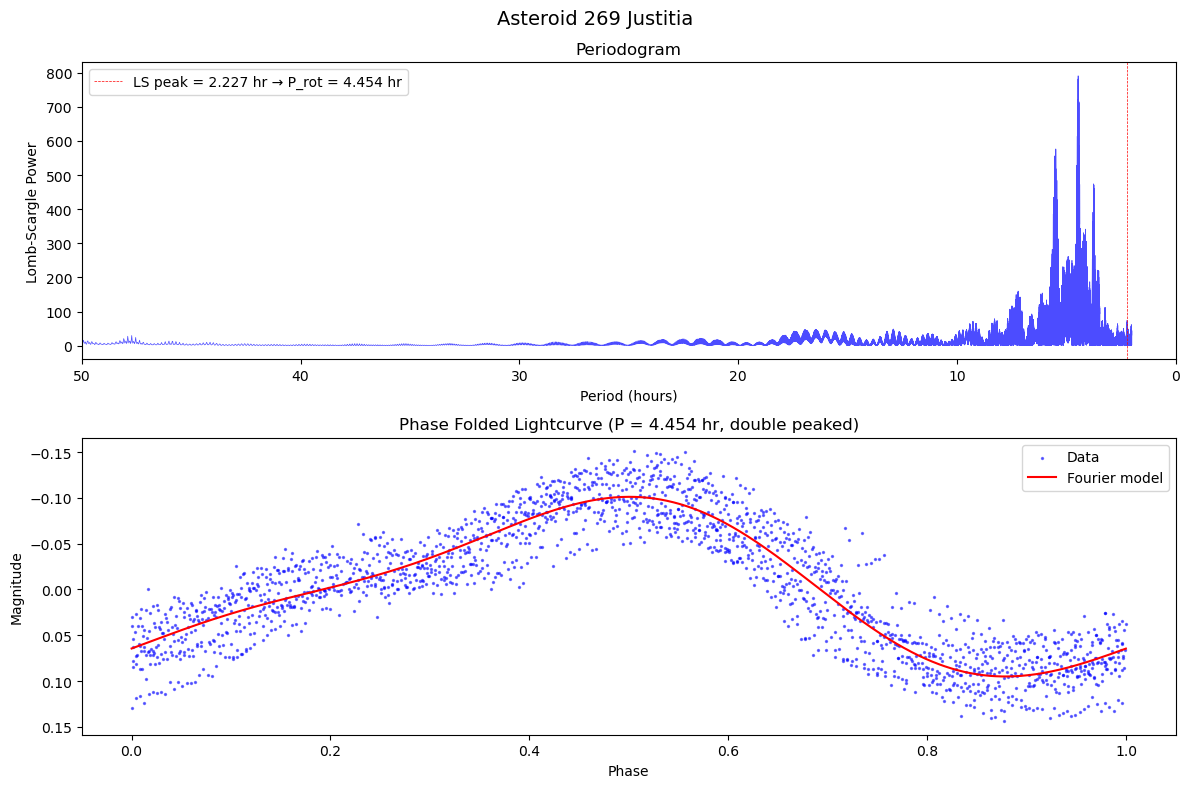

In [18]:
import pipeline.output_gen as og
importlib.reload(og)

fig, summary = og.generate_output(
    t=processed['jd_corrected'].values,
    y=processed[1].values,
    frequencies=frequencies,
    powers=powers,
    period_hours=period_hours,
    best_frot=best_frot,
    best_coeffs=best_coeffs,
    is_double_peaked=is_double_peaked,
    asteroid_name='269 Justitia',
    output_dir='../outputs'
)

In [19]:
frot, coeffs, chi2 = hl.refine_period(processed['jd_corrected'].values, processed[1].values, 1.5630)

Figure saved to ../outputs/269 Justitia_results.png


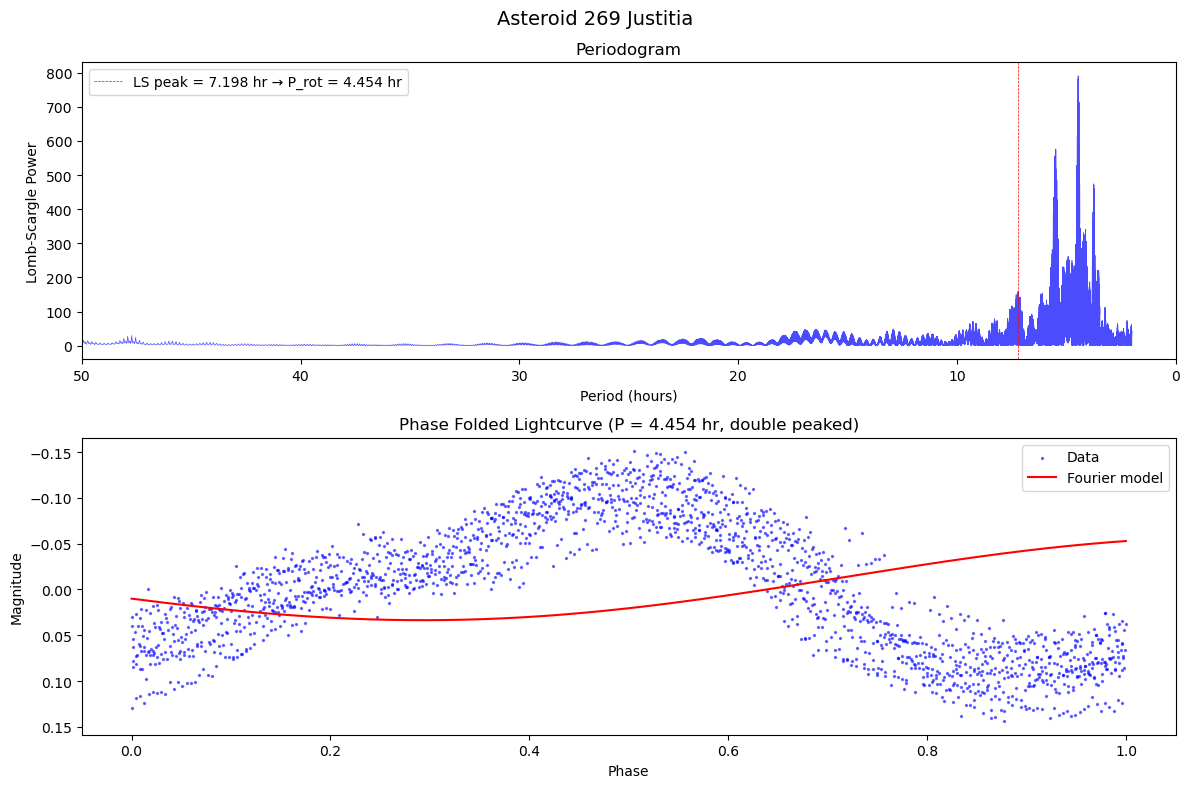

In [20]:
fig, summary = og.generate_output(
    t=processed['jd_corrected'].values,
    y=processed[1].values,
    frequencies=frequencies,
    powers=powers,
    period_hours=period_hours,
    best_frot=frot,
    best_coeffs=coeffs,
    is_double_peaked=is_double_peaked,
    asteroid_name='269 Justitia',
    output_dir='../outputs'
)